## Task 05
## A real time series (flights.csv)
144 rows: monthly airline passenger totals from 1949 to 1960. Columns: year, month, passengers.

Small and clean, so all the difficulty is in the chart design.


# Load and prepare the data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
path = "week 01 dataset/flights.csv"
df = pd.read_csv(path)

# Check data
print(df.shape)
display(df.head())
print(df.isna().sum())

(144, 3)


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


year          0
month         0
passengers    0
dtype: int64


In [3]:
# Convert year and month into a single date column
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str) + "-01"
)

# Sort by date
df = df.sort_values("date")

display(df.head())

,year,month,passengers,date
0,1949,January,112,1949-01-01
1,1949,February,118,1949-02-01
2,1949,March,132,1949-03-01
3,1949,April,129,1949-04-01
4,1949,May,121,1949-05-01


## 1. Passengers over time
Plot passengers over time as a single line. You will need to combine year and month into one ordered time axis first — this is the real work of the task.

**Chart type: Line chart**

**A line chart is the correct choice because this is a time series, and we want to see how passenger numbers change continuously from 1949 to 1960.**

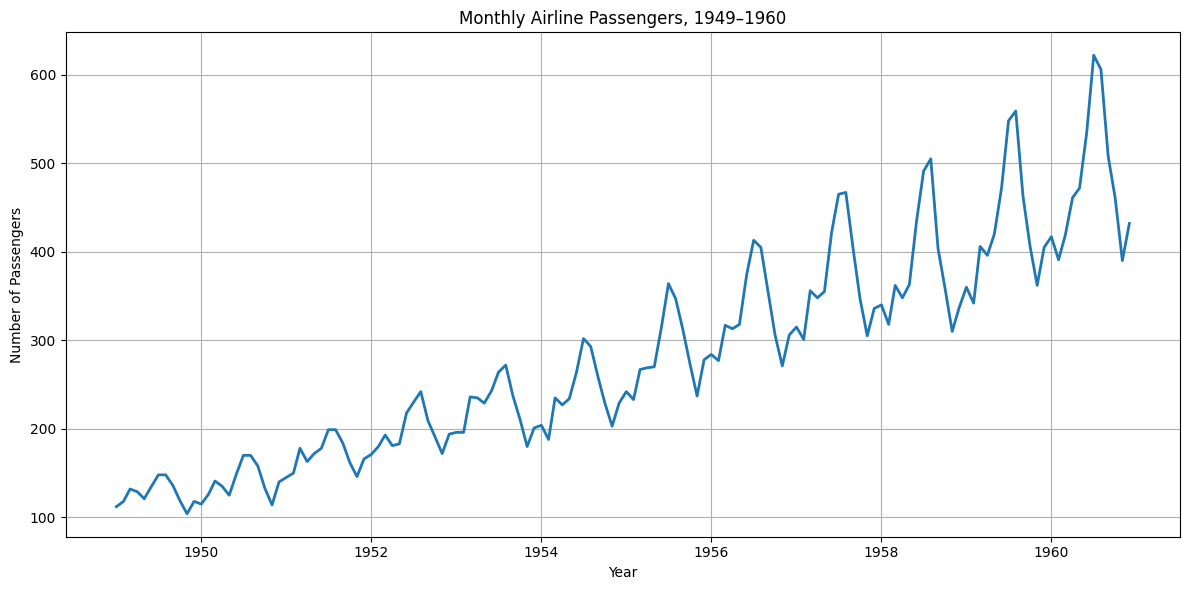

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["passengers"],
    linewidth=2
)

plt.title("Monthly Airline Passengers, 1949–1960")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Isolate the seasonal cycle
Your chart shows two patterns at once: a long-term rise and a repeating within-year cycle. Build a second chart that isolates the seasonal cycle alone (hint: one line per year, months on the x-axis).

**The question gives an important hint:**

**One line per year, months on the x-axis.**

**So we will put:**

**X-axis → month**
**Y-axis → passengers**
**Each line → one year**

 

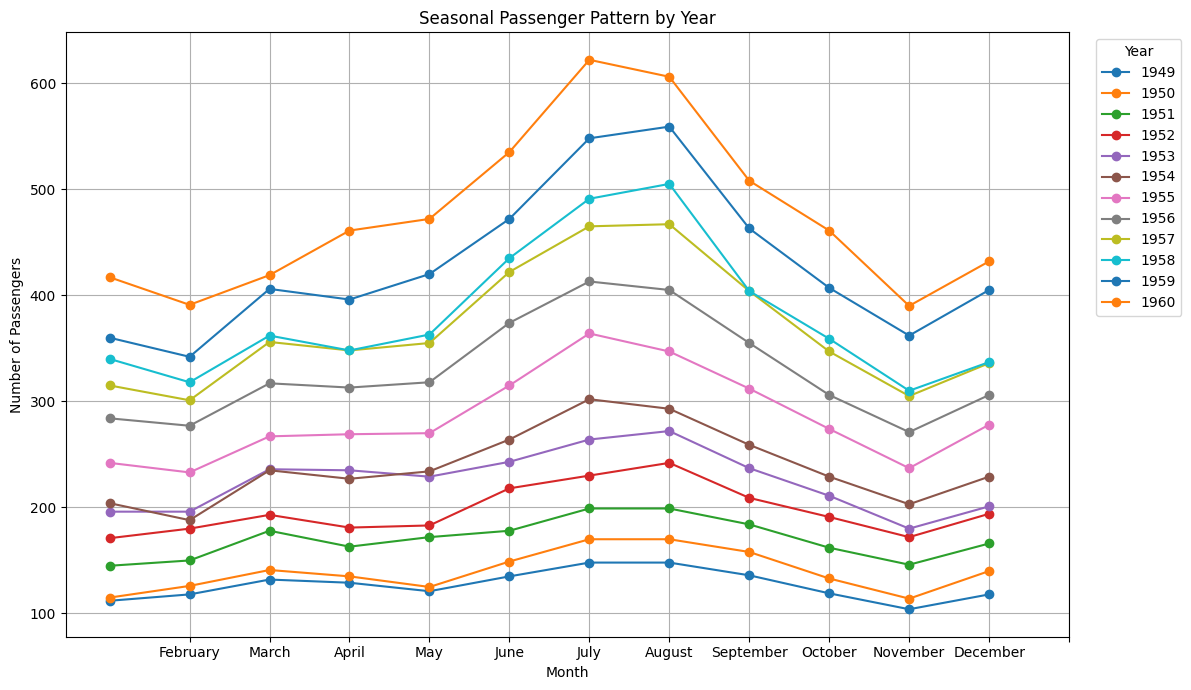

In [5]:
plt.figure(figsize=(12, 7))

for year, group in df.groupby("year"):
    plt.plot(
        group["month"],
        group["passengers"],
        marker="o",
        label=str(year)
    )

plt.title("Seasonal Passenger Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")

plt.xticks(range(1, 13))
plt.grid(True)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 3. Which month is consistently busiest
Which month is consistently busiest? Build a chart that makes this obvious at a glance.

**Chart type: Bar chart**

**A bar chart makes the comparison between months easy to see at a glance.**


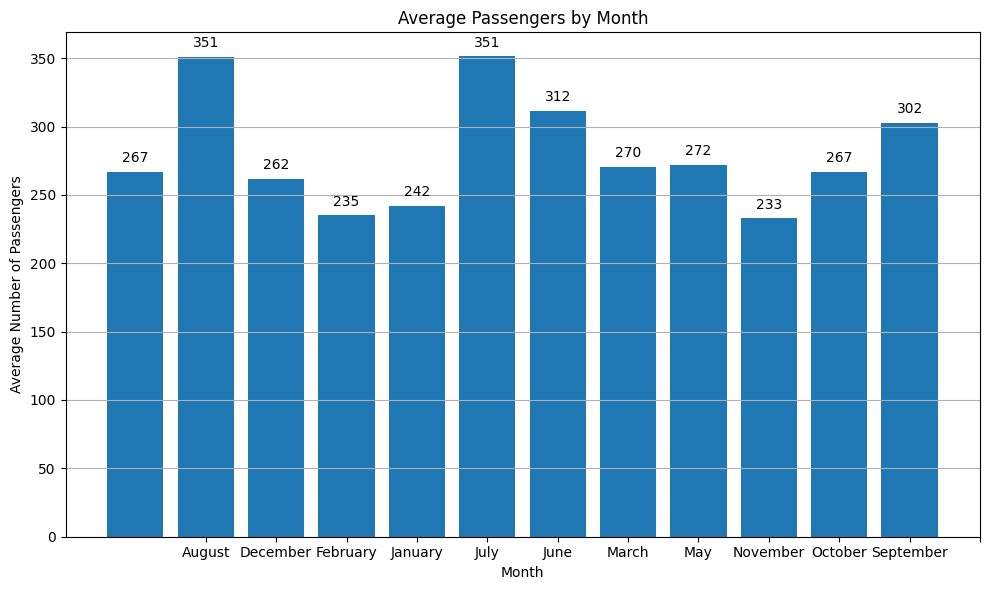

In [6]:
monthly_average = (
    df.groupby("month")["passengers"]
    .mean()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    monthly_average.index,
    monthly_average.values
)

plt.title("Average Passengers by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Passengers")

plt.xticks(range(1, 13))

# Add values above bars
for bar, value in zip(bars, monthly_average.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Justification**

A bar chart is appropriate because it makes the average passenger volume for each month easy to compare and immediately highlights the consistently busiest month.

For this dataset, July is the consistently busiest month on average.

**You can verify it directly with:**

In [7]:
busiest_month = monthly_average.idxmax()
busiest_value = monthly_average.max()

print("Busiest month:", busiest_month)
print("Average passengers:", busiest_value)

Busiest month: July
Average passengers: 351.3333333333333


## 4. chart in a report?
Write down which of your three charts you would put in a report, and why the other two do not belong in the same report.

**I would put the first chart in the report because it provides the clearest overall view of passenger growth and seasonality from 1949 to 1960. The second chart is more detailed and becomes visually crowded because it contains a separate line for every year, while the third chart summarizes the data by month and therefore hides the long-term growth trend.**

## Question to answer in writing
the seasonal swing gets visibly bigger every year. Is that because the seasonality is growing, or just because the airline is growing? Suggest a chart that would settle it.

Looking at Chart 1, the seasonal peaks appear to become larger every year.

But there are two possible explanations:

Explanation A — Seasonality is actually becoming stronger

For example:

January = 100
July    = 200

Seasonal difference:

200 - 100 = 100
Explanation B — The airline is simply getting bigger

Suppose later:

January = 300
July    = 600

The absolute difference is now:

600 - 300 = 300

It looks like seasonality has become much bigger.

But the relative seasonal pattern is exactly the same:

July / January = 2

So simply looking at the raw passenger numbers cannot distinguish these two explanations.

Chart that would settle it

We should normalize each year's passenger numbers by that year's average.

For every year:

Passenger value / yearly average

Then plot the normalized seasonal cycles.

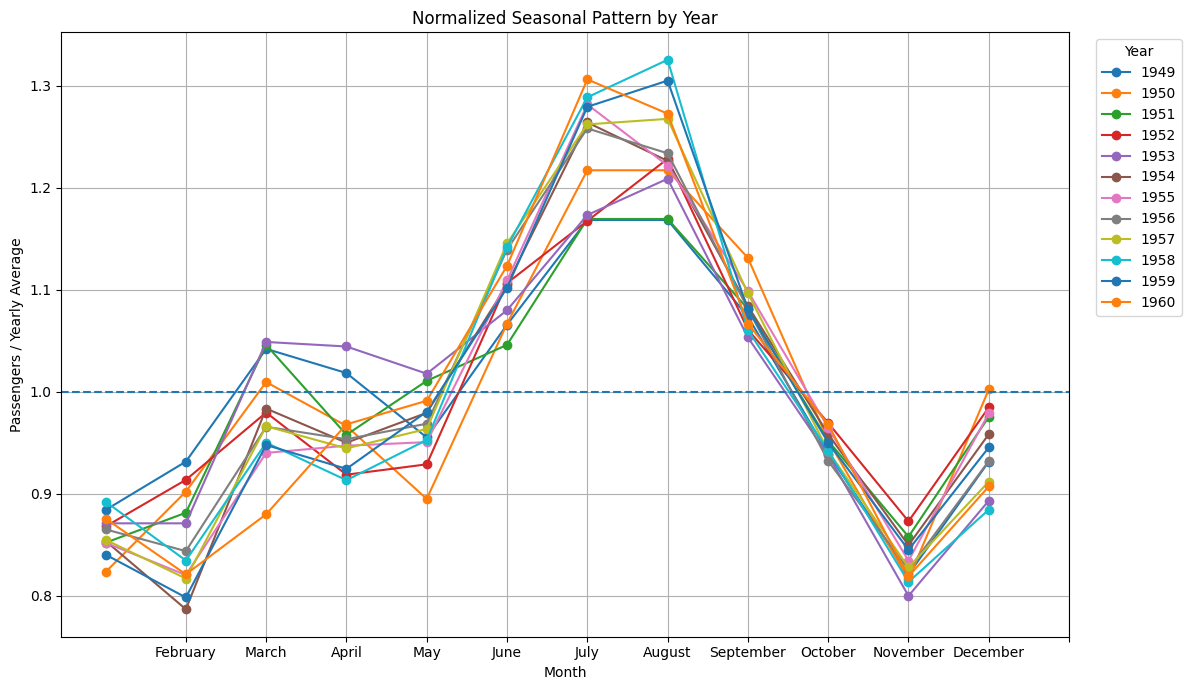

In [8]:
# Calculate each year's average passenger count
df["year_average"] = df.groupby("year")["passengers"].transform("mean")

# Normalize passenger numbers by the yearly average
df["relative_passengers"] = (
    df["passengers"] / df["year_average"]
)

plt.figure(figsize=(12, 7))

for year, group in df.groupby("year"):
    plt.plot(
        group["month"],
        group["relative_passengers"],
        marker="o",
        label=str(year)
    )

plt.axhline(
    1,
    linestyle="--"
)

plt.title("Normalized Seasonal Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Passengers / Yearly Average")

plt.xticks(range(1, 13))
plt.grid(True)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Why this chart works

A value of:

1.0

means the month is exactly at that year's average.

For example:

1.2 = 20% above that year's average
0.8 = 20% below that year's average

Now the overall growth of the airline has been removed.

**The larger seasonal swing may simply be caused by overall growth in passenger numbers rather than stronger seasonality. To distinguish these explanations, I would normalize each month's passenger count by the average passenger count for its year and plot the normalized values by month for each year. If the normalized seasonal curves remain similar over time, the larger absolute swings are mainly due to overall growth; if the curves become increasingly spread out, this would indicate that the seasonal effect itself is becoming stronger.**